# PRE-INGESTION EXPLORATORY EDA — AIHub 025 일상생활·구어체 한–영 병렬 말뭉치

> **Notebook status:** `SUPPORTING / EXPLORATORY / PRE-INGESTION EDA / NOT G1 PASS`

| Traceability field | Value |
|---|---|
| Dataset local ID | `AIHUB_025` |
| Inspected raw path | `/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이터` |
| File-family mapping | Training/Validation × EN→KO and KO→EN JSON; byte-identical source/label aliases and one validation ZIP |
| File hashes / source manifest | 이 notebook 실행 시 모든 physical file SHA-256과 `RAW_FILE_MANIFEST_SHA`를 계산해 아래 inventory 및 output CSV/JSON에 기록 |
| Audit timestamp | 실행 cell에서 local timezone ISO-8601로 기록 |
| Population scope | SHA-256 고유 JSON/XLSX content의 **FULL POPULATION aggregate** |
| Visualization sample | `BLAKE2b(seed=20260816) mod 1000 < 10`, 약 1%; scatter/sample preview에만 사용 |
| Raw mutation | 없음; `data/raw/**` read-only |

이 notebook은 raw 구조와 관측 분포를 시각적으로 이해하기 위한 supporting artifact다. pair validity, primary corpus 적합성, Tokenization Premium, 또는 QC acceptance를 판단하지 않는다.


## 1. 실행 환경과 snapshot contract

질문: **어떤 raw file에서 어떤 범위로 계산했는가?**

아래 cell은 worktree root를 자동 탐색하고 공용 streaming helper를 불러온다. 외부 다운로드는 없다.


In [1]:
from pathlib import Path
import json, sys
from IPython.display import Markdown, display

def find_worktree_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'outputs/eda_raw/support/raw_eda_framework.py').exists():
            return candidate
    raise FileNotFoundError('worktree root not found')

WORKTREE_ROOT = find_worktree_root(Path.cwd().resolve())
sys.path.insert(0, str(WORKTREE_ROOT / 'outputs/eda_raw/support'))
from raw_eda_framework import (
    profile_dataset, save_artifacts, plot_overview, plot_lengths,
    plot_categories, plot_quality,
)

CONFIG = {'dataset_local_id': 'AIHUB_025', 'dataset_title': 'AIHub 025 일상생활·구어체 한–영 병렬 말뭉치', 'short_name': 'daily_conversation_parallel', 'artifact_prefix': 'aihub_025', 'raw_dir': '/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이터', 'mapping': 'Training/Validation × EN→KO and KO→EN JSON; byte-identical source/label aliases and one validation ZIP', 'category_plot_dimensions': ['domain', 'subdomain', 'source', 'source_language']}
OUTPUT_DIR = WORKTREE_ROOT / 'outputs/eda_raw' / CONFIG['artifact_prefix']
FIGURE_DIR = WORKTREE_ROOT / 'outputs/figures/eda_raw' / CONFIG['artifact_prefix']
print('WORKTREE_ROOT =', WORKTREE_ROOT)
print('Python =', sys.executable)
print('RAW =', CONFIG['raw_dir'])


WORKTREE_ROOT = /home/sieg/projects-wsl/Tokenization_Premium/.agent_worktrees/raw-eda
Python = /home/sieg/projects-wsl/Tokenization_Premium/.venv/bin/python
RAW = /home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이터


## 2. Full-population streaming profile

질문: **전체 모집단의 규모·스키마·결측·길이·category·noise·중복 신호는 무엇인가?**

- JSON은 top-level `data[]`를 순차 파싱한다.
- XLSX는 `openpyxl(read_only=True)`로 행을 순차 처리한다.
- byte-identical source/label copies는 inventory에는 남기되 내용 집계는 SHA-256당 한 번만 한다.
- audit 중 size/mtime이 달라지면 결과 저장 전에 실행을 중단한다.


In [2]:
result = profile_dataset(CONFIG)
save_artifacts(result, OUTPUT_DIR)
display(Markdown('### Snapshot summary'))
display(result['summary'])
display(Markdown('### Physical file inventory and SHA-256'))
display(result['inventory'])


### Snapshot summary

{'dataset_local_id': 'AIHUB_025',
 'dataset_title': 'AIHub 025 일상생활·구어체 한–영 병렬 말뭉치',
 'audit_timestamp': '2026-08-16T14:09:02+09:00',
 'audit_completed_timestamp': '2026-08-16T14:09:58+09:00',
 'raw_dir': '/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/025.일상생활 및 구어체 한-영 번역 병렬 말뭉치 데이터',
 'physical_file_count': 9,
 'unique_content_file_count': 5,
 'profiled_unique_data_files': 4,
 'logical_record_count': 2700345,
 'sample_record_count': 27115,
 'population_scope': 'FULL POPULATION AGGREGATES over unique SHA-256 JSON/XLSX content',
 'sample_method': 'deterministic BLAKE2b(seed=20260816) hash threshold 10/1000 (~1%); scatter/sample only',
 'notebook_status': 'SUPPORTING / EXPLORATORY / PRE-INGESTION EDA / NOT G1 PASS',
 'raw_file_manifest_sha': '0571de91329994a1c9c703e58314457bdbcb6e30ed9380ec347c3f73d1269b13',
 'stability_counts': {'STABLE_FILE': 9,
  'DOWNLOAD_IN_PROGRESS': 0,
  'PARTIAL_DOWNLOAD': 0,
  'UNKNOWN': 0}}

### Physical file inventory and SHA-256

,relative_path,bytes,mtime_epoch_ns,sha256,format,split,role,direction,duplicate_of,stability_state
0,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,1009131497,1786853066489703121,922fa5e307d80436644f63ec180be387dc4b3c63b5ffaf...,JSON,TRAIN,LABEL,EN_TO_KO,,STABLE_FILE
1,01.데이터/1.Training/라벨링데이터/TL2/일상생활및구어체_한영_train...,972643210,1786853065411706074,5e0fdf49b5c7b3b1ca89b4e9c7b6d16c91f23b6a51e555...,JSON,TRAIN,LABEL,KO_TO_EN,,STABLE_FILE
2,01.데이터/1.Training/원천데이터/TS1/일상생활및구어체_영한_train_...,1009131497,1786853066614369444,922fa5e307d80436644f63ec180be387dc4b3c63b5ffaf...,JSON,TRAIN,SOURCE,EN_TO_KO,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,STABLE_FILE
3,01.데이터/1.Training/원천데이터/TS2/일상생활및구어체_한영_train_...,972643210,1786853065474039237,5e0fdf49b5c7b3b1ca89b4e9c7b6d16c91f23b6a51e555...,JSON,TRAIN,SOURCE,KO_TO_EN,01.데이터/1.Training/라벨링데이터/TL2/일상생활및구어체_한영_train...,STABLE_FILE
4,01.데이터/2.Validation/라벨링데이터/VL1/일상생활및구어체_영한_val...,131341219,1786853031931114004,ca574c2d5c14efd8513ed95a6a950ffe14896b1cfc1ada...,JSON,VALID,LABEL,EN_TO_KO,,STABLE_FILE
5,01.데이터/2.Validation/라벨링데이터/VL1/일상생활및구어체_한영_val...,121536888,1786853031443448673,02dce9c0cc9c6da6ef088b410715b0397d667f349ad05d...,JSON,VALID,LABEL,KO_TO_EN,,STABLE_FILE
6,01.데이터/2.Validation/원천데이터/VS1.zip,30422138,1786853025536464867,f7cd73e0be354dfa554cf7ca8ae1b30148d459a5d9b720...,ZIP,UNSPLIT,ARCHIVE,N/A,,STABLE_FILE
7,01.데이터/2.Validation/원천데이터/VS1/일상생활및구어체_영한_vali...,131341219,1786853031942113973,ca574c2d5c14efd8513ed95a6a950ffe14896b1cfc1ada...,JSON,VALID,SOURCE,EN_TO_KO,01.데이터/2.Validation/라벨링데이터/VL1/일상생활및구어체_영한_val...,STABLE_FILE
8,01.데이터/2.Validation/원천데이터/VS1/일상생활및구어체_한영_vali...,121536888,1786853031439782017,02dce9c0cc9c6da6ef088b410715b0397d667f349ad05d...,JSON,VALID,SOURCE,KO_TO_EN,01.데이터/2.Validation/라벨링데이터/VL1/일상생활및구어체_한영_val...,STABLE_FILE


## 3. 구조·규모·coverage

질문: **어떤 file group이 corpus 규모를 구성하고, core text/metadata coverage는 어떤가?**


,group,records
0,TRAIN · EN_TO_KO,1200307
1,TRAIN · KO_TO_EN,1200000
2,VALID · EN_TO_KO,150038
3,VALID · KO_TO_EN,150000


,group,field,records,absent,null,empty,missing_or_empty_rate,type_counts
66,VALID · KO_TO_EN,ner,150000,0,145598,0,0.970653,"{""dict"": 4402, ""null"": 145598}"
28,TRAIN · KO_TO_EN,ner,1200000,0,1164103,0,0.970086,"{""dict"": 35897, ""null"": 1164103}"
9,TRAIN · EN_TO_KO,ner,1200307,0,1153161,0,0.960722,"{""dict"": 47146, ""null"": 1153161}"
47,VALID · EN_TO_KO,ner,150038,0,143978,0,0.959610,"{""dict"": 6060, ""null"": 143978}"
0,TRAIN · EN_TO_KO,data_set,1200307,0,0,0,0.000000,"{""string"": 1200307}"
1,TRAIN · EN_TO_KO,domain,1200307,0,0,0,0.000000,"{""string"": 1200307}"
2,TRAIN · EN_TO_KO,en,1200307,0,0,0,0.000000,"{""string"": 1200307}"
3,TRAIN · EN_TO_KO,en_original,1200307,0,0,0,0.000000,"{""string"": 1200307}"
4,TRAIN · EN_TO_KO,file_name,1200307,0,0,0,0.000000,"{""string"": 1200307}"
5,TRAIN · EN_TO_KO,included_unknown_words,1200307,0,0,0,0.000000,"{""boolean"": 1200307}"


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 600.


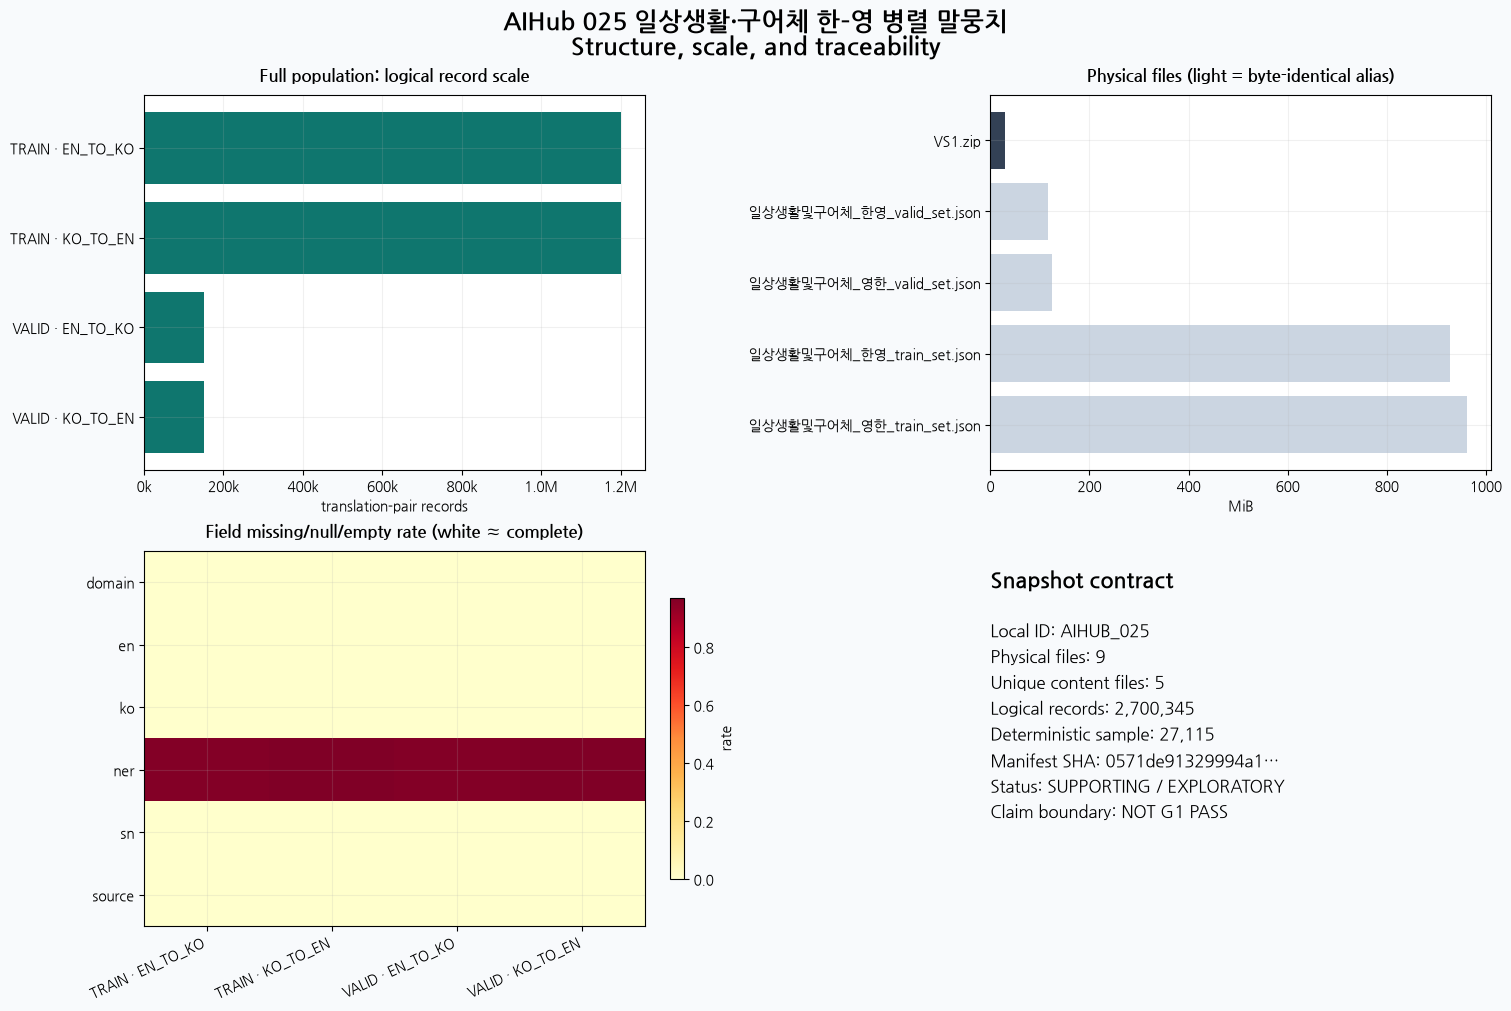

In [3]:
display(result['record_counts'].sort_values('records', ascending=False))
display(result['schema'].sort_values(['missing_or_empty_rate', 'group', 'field'], ascending=[False, True, True]).head(30))
plot_overview(result, FIGURE_DIR)


## 4. KO/EN raw length structure

질문: **raw codepoint/UTF-8 byte 길이의 중심·꼬리와 KO–EN 관계가 group별로 어떻게 다른가?**

위쪽 분포선과 p50/p95는 full population이다. hexbin만 deterministic 약 1% sample이다.


,group,language,metric,count,min,p50,p90,p95,p99,max,mean
0,TRAIN · EN_TO_KO,EN,codepoints,1200307,12,53,88,101,130,389,57.057381
2,TRAIN · EN_TO_KO,KO,codepoints,1200307,2,25,42,48,62,196,27.378756
4,TRAIN · KO_TO_EN,EN,codepoints,1200000,1,50,99,117,156,659,54.384740
6,TRAIN · KO_TO_EN,KO,codepoints,1200000,1,25,47,55,72,297,26.702073
8,VALID · EN_TO_KO,EN,codepoints,150038,13,59,98,111,141,399,63.722944
10,VALID · EN_TO_KO,KO,codepoints,150038,4,29,49,54,69,222,32.068556
12,VALID · KO_TO_EN,EN,codepoints,150000,1,50,99,117,156,543,54.346167
14,VALID · KO_TO_EN,KO,codepoints,150000,2,25,47,55,72,282,26.694520
1,TRAIN · EN_TO_KO,EN,utf8_bytes,1200307,12,53,88,101,130,389,57.058789
3,TRAIN · EN_TO_KO,KO,utf8_bytes,1200307,4,63,103,118,151,430,66.913455


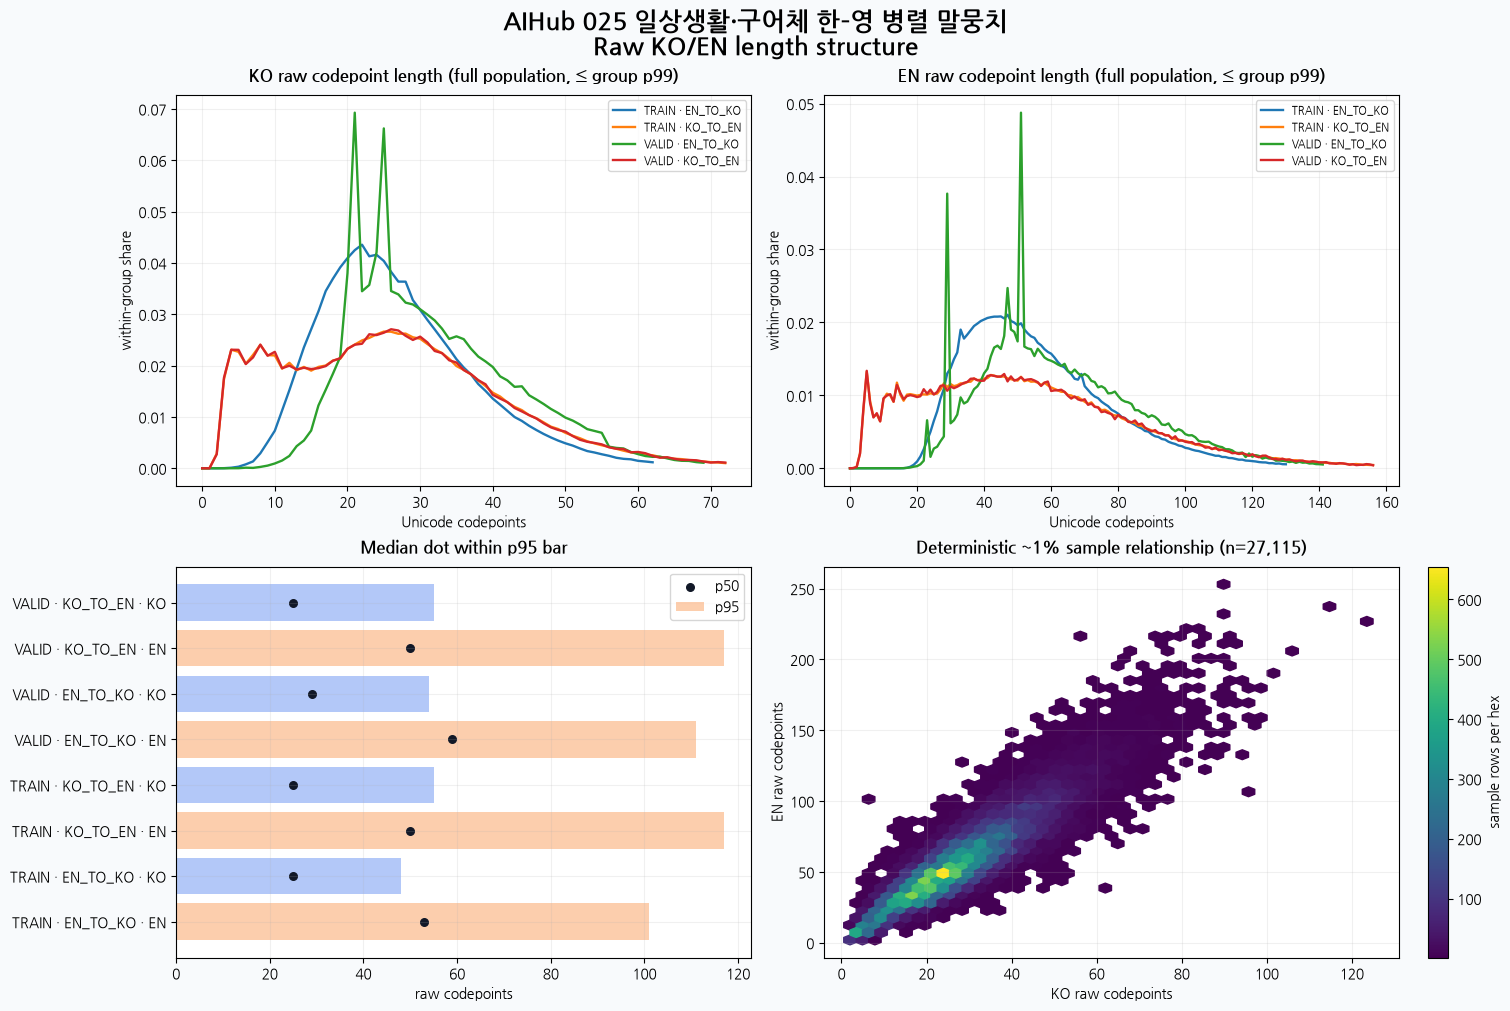

In [4]:
display(result['length_summary'].sort_values(['metric', 'group', 'language']))
plot_lengths(result, FIGURE_DIR)


## 5. Domain/source/category composition

질문: **어떤 source/domain/category가 실제 row volume을 구성하는가?**

범주 수가 큰 field는 top raw value만 시각화하며, 전체 count table은 CSV artifact로 남긴다.


,dimension,value,count
0,data_set,일상생활및구어체,2700345
3,domain,해외영업,1260367
1,domain,일상생활,899757
2,domain,해외고객과의채팅,540221
4,license,open,2700345
6,source,크라우드 소싱,1350345
7,source,크라우드소싱,900195
5,source,SBS,449805
8,source_language,en,1350345
9,source_language,ko,1350000


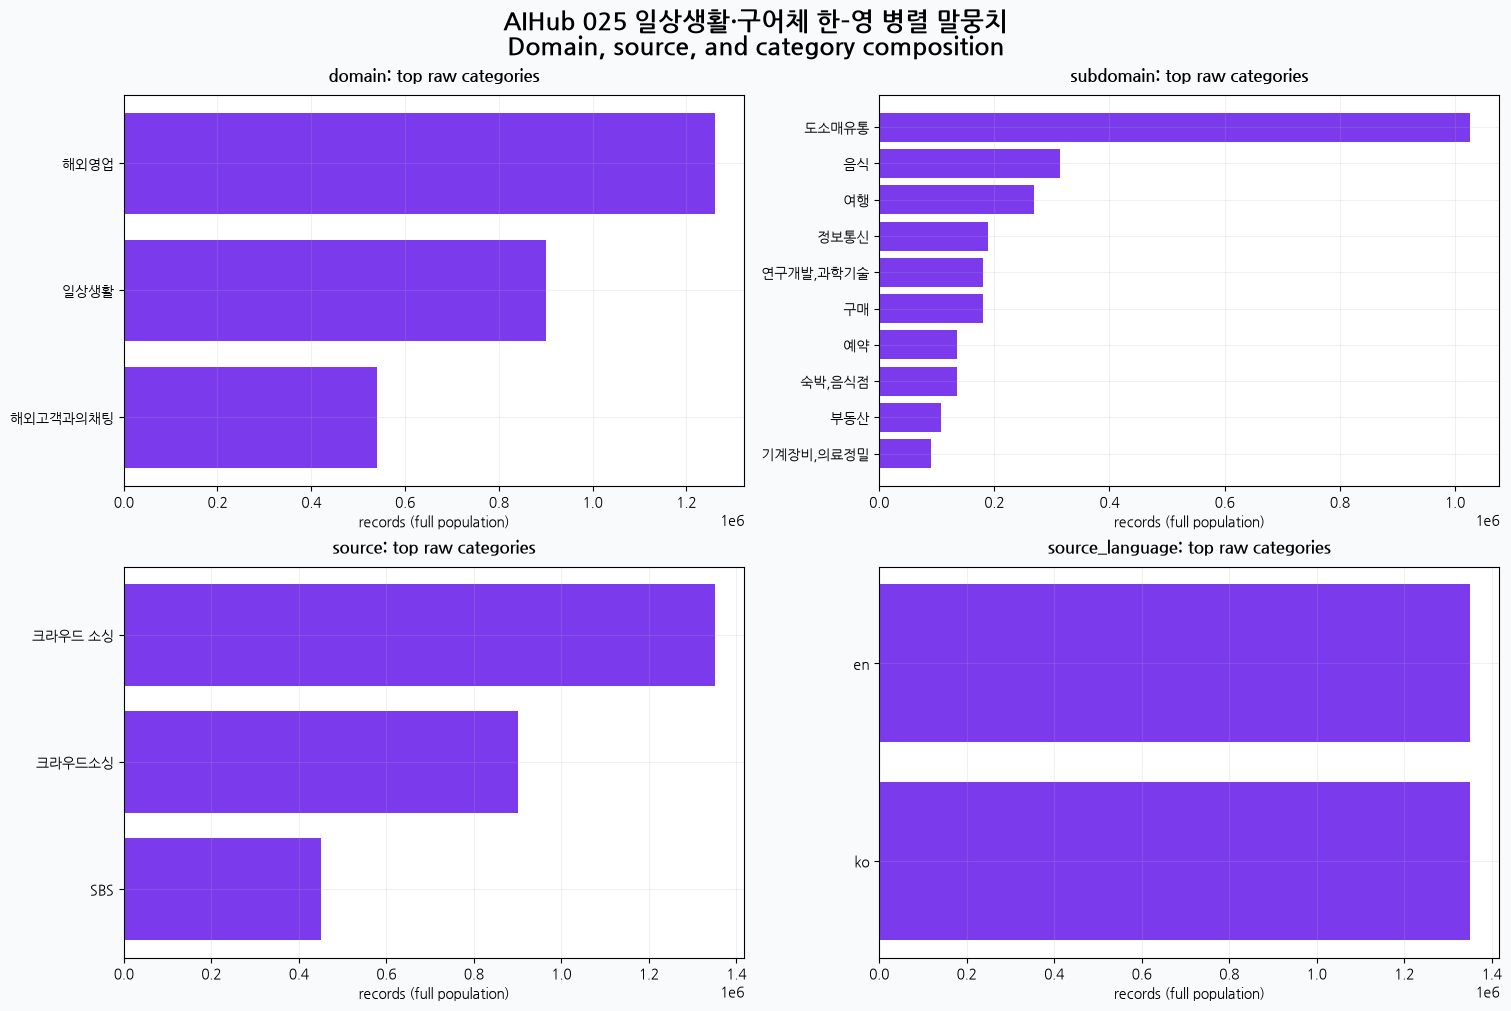

In [5]:
top_categories = (result['categories'].groupby(['dimension', 'value'], as_index=False)['count'].sum()
                  .sort_values(['dimension', 'count'], ascending=[True, False])
                  .groupby('dimension').head(10))
display(top_categories)
plot_categories(result, FIGURE_DIR)


## 6. Potential QC signals — acceptance가 아님

질문: **missing metadata, whitespace/script/markup 신호, raw duplicate 후보는 어디에 집중되는가?**

모든 항목은 `OBSERVED RAW DISTRIBUTION` 또는 `POTENTIAL QC ISSUE`다. 자동 오류 판정이나 정규화 근거가 아니다.


,scope,duplicate_pair_rows_after_first,distinct_duplicate_pair_hashes,validation_rows_overlapping_training_pair,candidate_method
0,dataset,214252,93823,47385,BLAKE2b-64 raw KO+EN; collision possible; no n...


,group,language,metric,row_count,records,rows_per_100k
12,VALID · EN_TO_KO,KO,cross_script,18324,150038,12212.906064
2,TRAIN · EN_TO_KO,KO,cross_script,107706,1200307,8973.204355
17,VALID · KO_TO_EN,KO,cross_script,12857,150000,8571.333333
6,TRAIN · KO_TO_EN,KO,cross_script,101667,1200000,8472.250000
18,VALID · KO_TO_EN,KO,expected_script_absent,487,150000,324.666667
7,TRAIN · KO_TO_EN,KO,expected_script_absent,3842,1200000,320.166667
14,VALID · KO_TO_EN,EN,expected_script_absent,177,150000,118.000000
4,TRAIN · KO_TO_EN,EN,expected_script_absent,1361,1200000,113.416667
11,VALID · EN_TO_KO,EN,zero_width,41,150038,27.326411
15,VALID · KO_TO_EN,EN,html_like,7,150000,4.666667


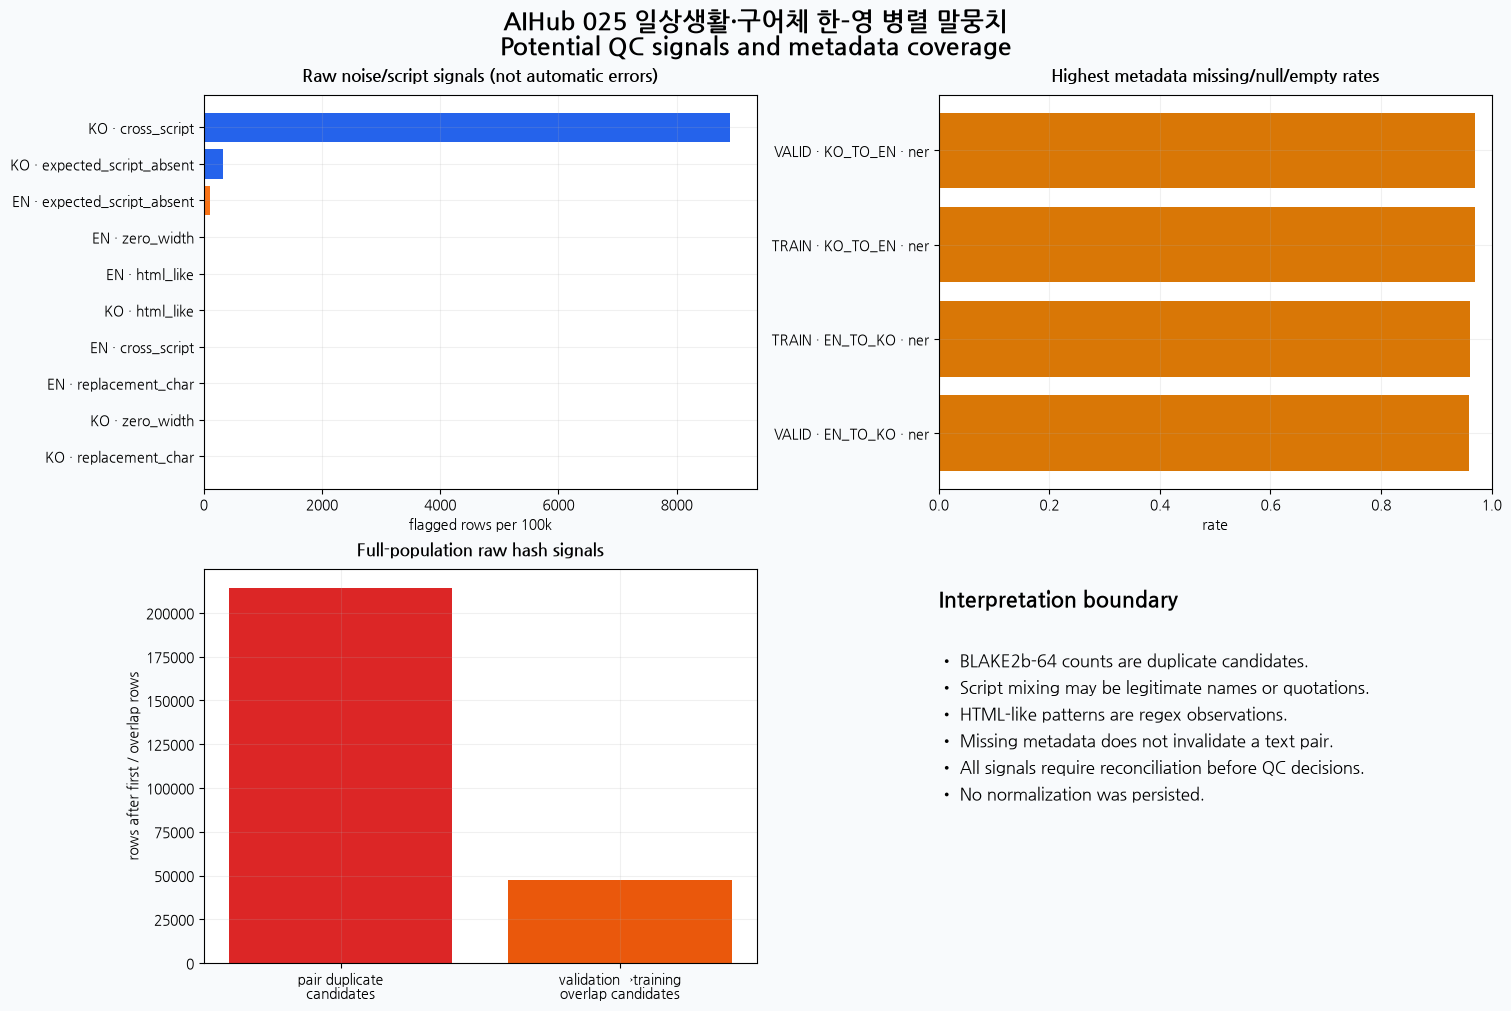

In [6]:
display(result['duplicates'])
display(result['noise'].sort_values('rows_per_100k', ascending=False).head(30))
plot_quality(result, FIGURE_DIR)


## 7. Deterministic sample structure

질문: **집계표 뒤의 실제 row 구조가 어떤 모습인가?**

아래 preview는 scatter와 동일한 deterministic hash sample 중 일부다. `ko_preview`/`en_preview`는 표시 길이를 160 codepoint로 제한하며 원문을 수정하지 않는다.


In [7]:
sample_columns = [c for c in ['group','relative_path','row_number','pair_key','ko_preview','en_preview','ko_codepoints','en_codepoints','domain','subdomain','source','대분류','소분류','상황','언론사','키워드','지자체'] if c in result['samples'].columns]
display(result['samples'][sample_columns].head(12))
print(f"sample rows = {len(result['samples']):,}; full logical records = {result['summary']['logical_record_count']:,}")


,group,relative_path,row_number,pair_key,ko_preview,en_preview,ko_codepoints,en_codepoints,domain,subdomain,source
0,TRAIN · EN_TO_KO,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,44,ECOAR1A00371,그 파일을 다른 이메일 주소로 보내주시겠어요?,Can you send me that file to another email add...,25,51,해외고객과의채팅,"숙박,음식점",크라우드 소싱
1,TRAIN · EN_TO_KO,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,264,ECOAR1D00271,"한국에 있는 다른 사업 벤처에 방문한다고 하셨는데, 그와 만날 수 있으면 좋을 것 ...",You mentioned that you'll be visiting your oth...,51,136,해외고객과의채팅,"숙박,음식점",크라우드 소싱
2,TRAIN · EN_TO_KO,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,306,ECOAR1D00614,열심히 노력한 보람이 있을 때 정말 행복하죠.,We surely feel happy when our hard work shows ...,25,58,해외고객과의채팅,"숙박,음식점",크라우드 소싱
3,TRAIN · EN_TO_KO,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,475,ECOAR1L00292,5명의 손님을 위한 테이블을 준비하겠습니다.,We will prepare a table for five guests.,24,40,해외고객과의채팅,"숙박,음식점",크라우드 소싱
4,TRAIN · EN_TO_KO,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,499,ECOAR1L00584,떡볶이에 대해서도 많이 들었어요.,"Also, I heard a lot about tteokbokki.",18,37,해외고객과의채팅,"숙박,음식점",크라우드 소싱
5,TRAIN · EN_TO_KO,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,663,ECOAR1R00080,케이터링을 맡아주실 수 있나요?,May I know if you can handle the catering?,17,42,해외고객과의채팅,"숙박,음식점",크라우드 소싱
6,TRAIN · EN_TO_KO,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,738,ECOAR1R00830,"죄송합니다, 고객님, 조정은 할 수 없습니다.","Sorry, sir, but no adjustments can be made.",25,43,해외고객과의채팅,"숙박,음식점",크라우드 소싱
7,TRAIN · EN_TO_KO,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,826,ECOAR1S00693,"안녕하세요, 그 호텔에 스파와 사우나가 있나요?","Hello, do you guys have a spa and sauna in you...",26,54,해외고객과의채팅,"숙박,음식점",크라우드 소싱
8,TRAIN · EN_TO_KO,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,833,ECOAR1S00784,오후 2시에 호텔에 체크인할 예정이니 오후 6시로 가능할까요?,I'll check in to the hotel at 2:00 p.m. so wou...,34,63,해외고객과의채팅,"숙박,음식점",크라우드 소싱
9,TRAIN · EN_TO_KO,01.데이터/1.Training/라벨링데이터/TL1/일상생활및구어체_영한_train...,999,ECOAR2C00439,"네, 저희 행사는 한국에서 열립니다.","Yes, our event will be held in Korea.",20,37,해외고객과의채팅,"숙박,음식점",크라우드 소싱


sample rows = 27,115; full logical records = 2,700,345


## 8. Interpretation scaffold

**Target 설계:** 이 supporting EDA에는 modeling target이 없다. 관찰 단위는 raw KO–EN pair와 file/group metadata다.

**관찰:** 실행 결과의 full-population tables와 네 개 figure에서 규모, 길이, 범주, 결측/noise 위치를 확인한다.

**원인 가설:** source, domain, 번역 방향, 문체, file generation 방식이 분포 차이에 관련될 수 있으나 이 notebook은 원인을 검정하지 않는다.

**제한:** deterministic sample plot은 모집단 aggregate가 아니며, 64-bit hash duplicate count에는 collision 가능성이 있다. 외부 AIHub 문서와 공식 release completeness는 확인하지 않는다.

**결론:** `OBSERVED RAW DISTRIBUTION`, `STRUCTURAL DATA CHARACTERISTIC`, `POTENTIAL QC ISSUE`, `REQUIRES RECONCILIATION` 범위에서만 해석한다. **NOT G1 PASS.**
